# The Gaia colour–magnitude diagram, by hand

Gaia measured trigonometric parallaxes for over a billion stars. A parallax is
a distance, and a distance turns an *apparent* magnitude into an *absolute*
one — turning a colour–magnitude diagram into a physical
**Hertzsprung–Russell diagram**, where stellar evolution can be read directly.

This notebook reproduces **Fig. 5c** of Gaia Collaboration, Babusiaux et al.
(2018), [A&A 616, A10](https://arxiv.org/abs/1804.09378): the HRD of the
**212,728 stars within 100 pc**, using the paper's own quality selection.

The plan mirrors the server's four tools:

1. get the 100 pc sample (bundled snapshot of the archive query),
2. apply the paper's quality filters — watching the star counts,
3. compute absolute magnitudes from inverted parallaxes,
4. draw the density diagram.

Then the same steps as MCP tools, and the tools as a server.

## 1. The sample

The real query is ADQL against `gaiadr2.gaia_source`:

```sql
SELECT source_id, parallax, parallax_over_error, phot_g_mean_mag, bp_rp, ...
FROM gaiadr2.gaia_source
WHERE parallax >= 10 AND parallax_over_error > 10
```

- `parallax >= 10` mas ⇒ distance < 100 pc (a volume-limited sphere),
- `parallax_over_error > 10` ⇒ distances good to ~10 %. This is what makes
  `d = 1/parallax` acceptable here: for noisy or negative parallaxes,
  inverting is biased or meaningless.
- **No `SELECT TOP N`** — a truncated result is *not* a random sample. (If
  you ever need an unbiased subsample, use Gaia's `random_index` column.)

A snapshot of the full query result ships with this repo, so everything below
works offline. `tools.gaia.query_archive()` runs the live query instead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tools import gaia

data = gaia.load_bundled(min_parallax_mas=10.0, min_parallax_snr=10.0)
print(f"{len(data):,} sources with parallax >= 10 mas and parallax SNR > 10")
print(f"columns: {data.dtype.names}")

439,019 sources with parallax >= 10 mas and parallax SNR > 10
columns: ('source_id', 'parallax', 'parallax_over_error', 'phot_g_mean_mag', 'bp_rp', 'phot_bp_rp_excess_factor', 'phot_g_mean_flux_over_error', 'phot_bp_mean_flux_over_error', 'phot_rp_mean_flux_over_error', 'visibility_periods_used', 'astrometric_chi2_al', 'astrometric_n_good_obs_al')


## 2. Why quality filters — the raw diagram first

Parallax and a G magnitude are enough to compute
$M_G = G + 5\log_{10}(\varpi/\mathrm{mas}) - 10$. Plot the sample *without*
photometric quality cuts and the HRD is there, but smeared: sources whose
BP/RP photometry is contaminated by a neighbour (blends) form a spurious
plume cutting across the diagram, and poor astrometric solutions scatter
everywhere.

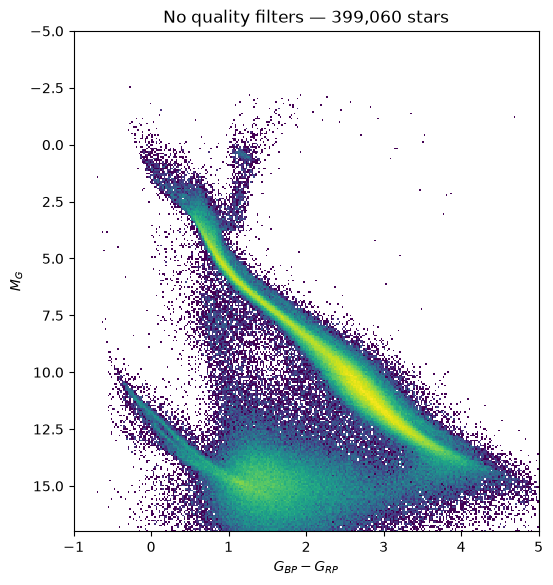

In [2]:
abs_g_raw = data["phot_g_mean_mag"] + 5 * np.log10(data["parallax"]) - 10

from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(6, 6.5))
ax.hist2d(data["bp_rp"], abs_g_raw, bins=300,
          range=[[-1, 5], [-5, 17]], norm=LogNorm(), cmap="viridis", cmin=1)
ax.set_ylim(17, -5)
ax.set_xlabel(r"$G_{BP} - G_{RP}$"); ax.set_ylabel(r"$M_G$")
ax.set_title(f"No quality filters — {np.isfinite(data['bp_rp']).sum():,} stars")
plt.show()

## 3. The published quality filters

Babusiaux et al. (2018), Sect. 2.1 — each cut, and why:

| filter | keeps | why |
|---|---|---|
| `phot_g_mean_flux_over_error > 50` | G good to ~2 % | magnitude errors small compared to HRD features |
| `phot_bp/rp_mean_flux_over_error > 20` | colour good to ~5 % | same, for the colour axis |
| `1.0+0.015(B\!-\!R)^2 < E < 1.3+0.06(B\!-\!R)^2` | uncontaminated BP/RP | removes blends — the spurious plume above |
| `visibility_periods_used > 8`, unit weight error < `1.2·max(1, e^{-0.2(G-19.5)})` | good astrometric fits | DR2-era precursor of the `RUWE < 1.4` cut |

Watch the counts: the published Fig. 5c sample is **212,728** stars.

In [3]:
n0 = len(data)
mask = gaia._g_snr(data, 50.0) & ~np.isnan(data["bp_rp"])
print(f"G flux SNR > 50:      {mask.sum():>9,} of {n0:,}")
mask &= gaia._bprp_snr(data, 20.0)
print(f"+ BP/RP flux SNR > 20: {mask.sum():>9,}")
mask &= gaia._excess_factor(data)
print(f"+ excess factor cut:   {mask.sum():>9,}")
mask &= gaia._astrometry(data)
print(f"+ astrometry cut:      {mask.sum():>9,}")

clean = data[mask]
print(f"\npublished Fig. 5c count: {gaia.PUBLISHED_100PC_COUNT:,}")

G flux SNR > 50:        383,149 of 439,019
+ BP/RP flux SNR > 20:   284,639
+ excess factor cut:     251,719
+ astrometry cut:        212,728

published Fig. 5c count: 212,728


## 4. The Hertzsprung–Russell diagram

Absolute magnitude from the inverted parallax (safe *only* because of the
SNR > 10 cut), then a log-scaled density map, bright stars at the top —
axes matched to the published figure.

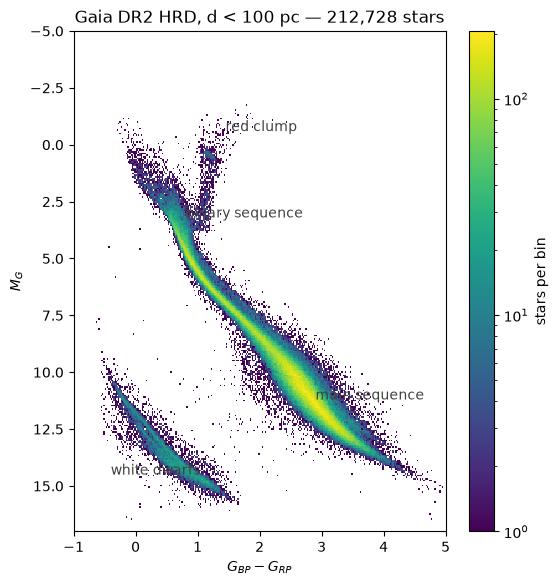

In [4]:
abs_g = clean["phot_g_mean_mag"] + 5 * np.log10(clean["parallax"]) - 10

fig, ax = plt.subplots(figsize=(6, 6.5))
h = ax.hist2d(clean["bp_rp"], abs_g, bins=300,
              range=[[-1, 5], [-5, 17]], norm=LogNorm(), cmap="viridis", cmin=1)
ax.set_ylim(17, -5)
ax.set_xlabel(r"$G_{BP} - G_{RP}$"); ax.set_ylabel(r"$M_G$")
ax.set_title(f"Gaia DR2 HRD, d < 100 pc — {len(clean):,} stars")
fig.colorbar(h[3], ax=ax, label="stars per bin")

ax.annotate("main sequence", (2.9, 11.2), color="0.25")
ax.annotate("binary sequence", (0.8, 3.2), color="0.25")
ax.annotate("red clump", (1.45, -0.6), color="0.25")
ax.annotate("white dwarfs", (-0.4, 14.5), color="0.25")
plt.show()

Everything the mini-project asks for is visible: the **main sequence**, the
**binary sequence** running parallel just above it (unresolved pairs are up
to 0.75 mag brighter), the **red clump** of core-helium-burning giants, and
the **white dwarf sequence** in the lower left.

Two completeness caveats worth stating with any version of this figure:

- the sample is volume-limited in parallax but **magnitude-limited in G** —
  the faint end (late M dwarfs, cool white dwarfs) is incomplete;
- the parallax-SNR cut removes faint red stars preferentially — a *bias*,
  not just a smaller sample.

## 5. The same science as tools

The four functions in `tools/cmd_tools.py` are the pipeline above with file
paths in between: each tool writes a CSV (or PNG) and returns
`{status, files, message, metadata}`. They are plain Python — call them
directly.

In [5]:
from tools import (fetch_gaia_sample, apply_quality_filters,
                   compute_absolute_magnitudes, plot_cmd,
                   compare_distance_shells)

OUTPUT_DIR = "output"

r1 = fetch_gaia_sample(OUTPUT_DIR, source="bundled")
print(r1.message)

r2 = apply_quality_filters(r1.files[0], OUTPUT_DIR)
print(r2.message)
for name, n in r2.metadata["removed_by_each_filter_alone"].items():
    print(f"  {name}: removes {n:,} on its own")

r3 = compute_absolute_magnitudes(r2.files[0], OUTPUT_DIR)
print(r3.message)

r4 = plot_cmd(r3.files[0], OUTPUT_DIR)
print(r4.message)
print(r4.files)

Fetched 439,019 Gaia DR2 sources with parallax >= 10 mas and parallax SNR > 10 from the bundled.


Quality filters kept 212,728 of 439,019 stars (published 100 pc count: 212,728).
  phot_g_snr: removes 55,870 on its own
  phot_bprp_snr: removes 152,502 on its own
  excess_factor: removes 159,033 on its own
  astrometry: removes 195,600 on its own


Computed M_G for 212,728 stars.


Plotted the density CMD of 212,728 stars (published Fig. 5c count: 212,728).
['/Users/nesar/Projects/Tutorials/gaia-mcp-server/notebooks/output/gaia_cmd_hrd.png']


## 6. The tools as an MCP server

The generic wrapper in `mcp_server/` reads `[tool.mcp-server]` from
`pyproject.toml`, imports `tools`, and registers every function in its
`__all__`. Your type hints and docstrings become the schema agents see:

In [6]:
from mcp_server.server import create_server

mcp = create_server()
for tool in await mcp.list_tools():
    required = [n for n, s in tool.inputSchema["properties"].items()
                if n in tool.inputSchema.get("required", [])]
    print(f"{tool.name:28s} required args: {required}")

fetch_gaia_sample            required args: ['output_dir']
apply_quality_filters        required args: ['input_file', 'output_dir']
compute_absolute_magnitudes  required args: ['input_file', 'output_dir']
plot_cmd                     required args: ['input_file', 'output_dir']
compare_distance_shells      required args: ['input_file', 'output_dir']


/Users/nesar/anaconda3/envs/spectra-tutorial/lib/python3.12/site-packages/pydantic_settings/sources/utils.py:47: IncompleteFieldDefinitionWarning: Field 'lifespan' has an incomplete definition: its annotation contains an unresolved forward reference, so settings sources may fail to correctly resolve its value. Call `model_rebuild()` on the model where the field is defined, once all the referenced types are defined.
  warnings.warn(


## 7. Run it as a real server

In a terminal (same conda env):

```bash
python -m mcp_server --transport streamable-http --port 8000
```

Clients connect to `http://127.0.0.1:8000/mcp` — for example the LangGraph
multi-agent client in
[`multiagent-client-demo`](https://github.com/HEP-KE/multiagent-client-demo),
which drives this server exactly as it drives `spectra-mcp-server`.

**Questions to think about** (from the mini-project):

- Why is inverting the parallax an unsafe distance estimator in general, and
  why is it acceptable at 100 pc?
- A cut on parallax signal-to-noise improves distances but biases the
  sample. How?
- Your sample is volume-limited in parallax but magnitude-limited in G.
  Which parts of the diagram are incomplete?